
Продолжаем четвертый модуль с основ RAG-систем — теперь уже семинар.

Collab семинара можно найти по [ссылке](https://colab.research.google.com/drive/1KwF06F2YJnYSZK3Bosl5RpETGg7SINP0?usp=sharing).

### Домашнее задание 11

1. **Выделить из собранного ранее датасета из ТГ-каналов/сайтов золотой набор** (либо руками, либо сгенерировать при помощи LLM)

   * оставить описание процесса сбора датасета;
     описать, какую часть вопросов из ретрива данный золотой набор покрывает и почему;
     объяснить выбор размера золотого набора — ***2 балла***
   * **бонусный балл** — за лексическое и лингвистическое разнообразие вопросов (ошибки, опечатки, различная длина и детализация вопросов) — ***1 балл***

2. **Протестировать ретриверы на золотом наборе:**

   * объяснить, по какому принципу считали "попадание" в контекст, какие метрики выбрали для оценки качества ретрива — ***1 балл***
   * протестировать различные ретриверы на данных, обосновать выбор — ***1 балл***
   * бонусный балл — протестировать методы query expansion и другие методы из langchain — ***1 балл***

3. **Добавить к системе реранкер, замерить улучшение/ухудшение качества ретрива**, замерить время, требуемое на запрос, и его изменение — ***1 балл***

4. **Протестировать оценку LLM-кой релевантности и выбора контекстов**, замерить улучшение/ухудшение качества ретрива, замерить время, требуемое на запрос, и его изменение — ***1 балл***

5. **Сгенерировать ответы модели на вопросы из золотого набора, разметить сгенерированные данные** — аргументировать метод разметки; если это LLM-as-a-judge, обосновать надёжность промпта и выбранного подхода — ***2 балла***

---

**Домашнее задание необходимо предоставить в формате ссылки на Google Colab/Jupyter Notebook с вашими действиями и ключевыми выводами.**

* 13 ноября 23:59 — мягкий дедлайн
* 20 ноября 23:59 — жесткий дедлайн

До мягкого дедлайна можно получить **10 баллов**, после — **5 баллов**.
Работы, отправленные после 20 ноября, могут быть проверены до конца курса в формате *зачет/незачет*.


In [1]:
!pip install -U datasets==3.6.0 huggingface_hub fsspec

  Using cached huggingface_hub-1.1.2-py3-none-any.whl.metadata (13 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
Using cached huggingface_hub-1.1.2-py3-none-any.whl (514 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.56.2 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.1.2 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

## Загрузка и подготовка данных

In [3]:
df = pd.read_csv('./data/channel_name.csv')
df.head()

,id,date,text
0,1201,2025-09-30T08:59:04+00:00,До Стачки осталось совсем немного времени. Под...
1,1198,2025-09-24T08:11:52+00:00,FlutterCon Europe 25 начался 🚀🚀🚀\nКстати орган...
2,1197,2025-09-19T14:29:48+00:00,"Итак, розыгрыш ""несуществующих билетов"" для сб..."
3,1196,2025-09-19T12:32:18+00:00,Очередной выпуск Observable Flutter посвящён р...
4,1195,2025-09-17T11:51:03+00:00,В этот раз на “Стачке” Flutter-у будет посвяще...


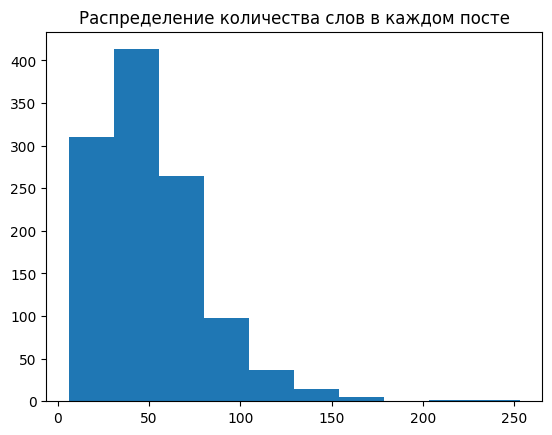

In [4]:
import matplotlib.pyplot as plt

df['word_count'] = df['text'].fillna('').str.split().str.len()

plt.hist(df['word_count'].values)
plt.title("Распределение количества слов в каждом посте");

### Метод выбора постов

In [5]:
import pandas as pd

# Загружаем датасет
df['date'] = pd.to_datetime(df['date'])

# Определяем категории по хештегам/ключевым словам
def categorize_post(text):
    if "#event" in text.lower():
        return "event"
    elif "#video" in text.lower():
        return "video"
    elif "#article" in text.lower():
        return "article"
    elif "#packageoftheweek" in text.lower():
        return "package"
    else:
        return "other"

df['category'] = df['text'].apply(categorize_post)

# Сортируем по дате для равномерного покрытия
df = df.sort_values('date')

# Выбираем репрезентативные посты по категориям
selected_posts = []

categories = df['category'].unique()
for cat in categories:
    cat_posts = df[df['category']==cat]
    # Берём 1-2 поста с равным распределением по дате
    step = max(1, len(cat_posts)//2)
    selected_posts.extend(cat_posts.iloc[::step].head(2)['id'].tolist())

# Если меньше 8 постов — добавляем ещё по датам
while len(selected_posts) < 8:
    remaining = df[~df['id'].isin(selected_posts)]
    selected_posts.append(remaining.iloc[0]['id'])

print("Выбранные посты для золотого набора:", selected_posts)


Выбранные посты для золотого набора: [4, 426, 322, 684, 500, 845, 531, 796, 610, 966]


In [6]:
# selected_posts — список ID постов, которые мы выбрали
# Например: selected_posts = [1201, 1196, 1195, 1193]

# Получаем срез df только с выбранными постами
golden_df = df[df['id'].isin(selected_posts)].copy()

# Просмотр первых строк
golden_df.head()


,id,date,text,word_count,category
1143,4,2020-09-30 11:33:26+00:00,Привет! \n\nЭто канал о Flutter-разработке. \n...,21,other
832,322,2021-12-22 13:45:00+00:00,Вам надоело заставлять пользователей загружать...,40,package
730,426,2022-05-04 07:43:06+00:00,Студия Oxymob ищет Middle / Middle+ / Senior F...,61,other
656,500,2022-07-21 13:45:01+00:00,В геймдеве есть довольно удобный подход с испо...,52,article
625,531,2022-08-31 07:48:04+00:00,Если вам нравится читать размышления в формате...,35,event


In [7]:
golden_df.to_csv('./data/golden_df.csv')

### 1. **Выделить из собранного ранее датасета из ТГ-каналов/сайтов золотой набор** (либо руками, либо сгенерировать при помощи LLM)

   * оставить описание процесса сбора датасета;
     описать, какую часть вопросов из ретрива данный золотой набор покрывает и почему;
     объяснить выбор размера золотого набора — ***2 балла***
   * **бонусный балл** — за лексическое и лингвистическое разнообразие вопросов (ошибки, опечатки, различная длина и детализация вопросов) — ***1 балл***

#### 1 Установка зависимостей

In [8]:
!pip install openai pandas tqdm sentence-transformers editdistance python-dotenv


  Using cached huggingface_hub-0.36.0-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-0.36.0-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.1.2
    Uninstalling huggingface_hub-1.1.2:
      Successfully uninstalled huggingface_hub-1.1.2

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


#### Импорт и настройка

In [9]:
import pandas as pd
import re
import random
from tqdm.auto import tqdm
import requests
from sentence_transformers import SentenceTransformer, util

# твоя функция для доступа к LLM
def chat_completion(messages, model="gpt-3.5-turbo", max_tokens=100, temperature=0.7, url="http://localhost:8000/v1/chat/completions", delay=1.0):
    headers = {"Content-Type": "application/json"}
    data = {"model": model, "max_tokens": max_tokens, "temperature": temperature, "messages": messages}
    try:
        response = requests.post(url, headers=headers, json=data, timeout=30)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при отправке запроса: {e}")
        return None


/Users/sergey/Projects/GigaSchool/llm-engineer/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W1107 12:42:24.623000 33595 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [ ]:
import requests
import time

def chat_completion(messages, model="gpt-3.5-turbo", max_tokens=100, temperature=0.7,
                    url="http://localhost:8000/v1/chat/completions", delay=1.0, timeout=30):
    """
    Универсальный метод для отправки запросов к chat completion API с задержкой
    
    Args:
        messages (list): Список сообщений в формате [{"role": "...", "content": "..."}]
        model (str): Название модели
        max_tokens (int): Максимальное количество токенов в ответе
        temperature (float): Температура для генерации
        url (str): URL эндпоинта
        delay (float): Задержка в секундах перед запросом
    
    Returns:
        dict: Ответ от сервера или None в случае ошибки
    """
    
    time.sleep(delay)  # <-- добавляем задержку перед отправкой запроса
    
    headers = {"Content-Type": "application/json"}
    
    data = {
        "model": model,
        "max_tokens": max_tokens,
        "temperature": temperature,
        "messages": messages
    }
    
    try:
        response = requests.post(url, headers=headers, json=data, timeout=timeout)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"Ошибка при отправке запроса: {e}")
        return None


#### Генерация кандидатов через локальный LLM

In [11]:
PROMPTS = {
    "fact_extraction": "Дай 5 вопросов, чтобы извлечь фактическую информацию из текста: '''{text}'''",
    "opinion_followup": "Сгенерируй 5 вопросов для обсуждения или мнений по тексту: '''{text}'''",
    "link_request": "Сгенерируй 4 вопроса, просящие ссылки/ресурсы/даты событий: '''{text}'''",
    "clarification": "Сгенерируй 4 уточняющих/неоднозначных вопроса по тексту: '''{text}'''"
}

def generate_questions_local(text, prompts=PROMPTS, model="gpt-3.5-turbo"):
    candidates = []
    for key, template in prompts.items():
        prompt = template.format(text=text)
        resp = chat_completion([{"role":"system","content":"Ты ассистент для генерации вопросов."},
                                {"role":"user","content":prompt}], model=model, max_tokens=300, temperature=0.9)
        if not resp: 
            continue
        out_text = resp['choices'][0]['message']['content']
        lines = re.split(r'[\n\r]+', out_text)
        for line in lines:
            line = line.strip()
            if line.endswith('?') or len(line.split()) <= 6:
                line = re.sub(r'^\d+\.\s*', '', line)
                candidates.append({"question": line, "prompt_type": key})
    return candidates


#### Генерация для всего датасета

In [12]:
df = pd.read_csv('./data/golden_df.csv')
df.shape

(10, 6)

In [13]:
df.head()

,Unnamed: 0,id,date,text,word_count,category
0,1143,4,2020-09-30 11:33:26+00:00,Привет! \n\nЭто канал о Flutter-разработке. \n...,21,other
1,832,322,2021-12-22 13:45:00+00:00,Вам надоело заставлять пользователей загружать...,40,package
2,730,426,2022-05-04 07:43:06+00:00,Студия Oxymob ищет Middle / Middle+ / Senior F...,61,other
3,656,500,2022-07-21 13:45:01+00:00,В геймдеве есть довольно удобный подход с испо...,52,article
4,625,531,2022-08-31 07:48:04+00:00,Если вам нравится читать размышления в формате...,35,event


In [14]:
df = pd.read_csv('./data/golden_df.csv')
df['date'] = pd.to_datetime(df['date'])

all_candidates = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    cands = generate_questions_local(row['text'])
    for c in cands:
        c['post_id'] = row['id']
    all_candidates.extend(cands)

candidates_df = pd.DataFrame(all_candidates).drop_duplicates(subset=['post_id','question'])


  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [02:36<00:00, 15.63s/it]


In [15]:
candidates_df

,question,prompt_type,post_id
0,Что представляет собой данный канал?,fact_extraction,4
1,Какую информацию можно найти на канале?,fact_extraction,4
2,Какие разделы содержит канал?,fact_extraction,4
3,Какие типы контента публикуются на канале?,fact_extraction,4
4,Какие возможности предоставляет канал по теме ...,fact_extraction,4
...,...,...,...
176,Какие хэштеги связаны с этим стримом?,link_request,966
177,Какие именно аспекты переезда Freezed на макро...,clarification,966
178,Какие новые возможности или функционал ожидают...,clarification,966
179,"Какие конкретные темы или вопросы, связанные с...",clarification,966


In [16]:
candidates_df.to_csv('./data/candidates_raw_df.csv')

#### Добавление опечаток

In [17]:
def make_typos(q, n=2):
    letters = list(q)
    res = set()
    for _ in range(n*3):
        s = letters.copy()
        typ = random.choice(['swap','del','replace'])
        if typ == 'swap' and len(s) >= 2:
            i = random.randrange(len(s)-1)
            s[i], s[i+1] = s[i+1], s[i]
        elif typ == 'del' and len(s) >= 1:
            i = random.randrange(len(s))
            del s[i]
        elif typ == 'replace' and len(s) >= 1:
            i = random.randrange(len(s))
            s[i] = random.choice('абвгдеёжзийклмнопрстуфхцчшщьыъэюяaeiou')
        cand = ''.join(s)
        if cand != q: res.add(cand)
        if len(res) >= n: break
    return list(res)

augmented = []
for _, r in candidates_df.iterrows():
    augmented.append({**r, "variation_type": "original"})
    for t in make_typos(r['question']):
        augmented.append({**r, "question": t, "variation_type": "typo"})

candidates_df = pd.DataFrame(augmented).drop_duplicates(subset=['post_id','question'])


In [18]:
candidates_df.to_csv('./data/candidates_df.csv')

In [19]:
candidates_df

,question,prompt_type,post_id,variation_type
0,Что представляет собой данный канал?,fact_extraction,4,original
1,Что представляет собой дхнный канал?,fact_extraction,4,typo
2,Что представялет собой данный канал?,fact_extraction,4,typo
3,Какую информацию можно найти на канале?,fact_extraction,4,original
4,Какую информацию можно найти на канлае?,fact_extraction,4,typo
...,...,...,...,...
538,"Какие конкретные темы или вопросы, связанные с...",clarification,966,typo
539,"Какие конкретные темы или вопросы, связанные с...",clarification,966,typo
540,Какие особенности и преимущества использования...,clarification,966,original
541,Какие особенности и преимуществаиспользования ...,clarification,966,typo


#### Семантическая диверсификация

In [20]:
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
questions = candidates_df['question'].tolist()
embs = embed_model.encode(questions, convert_to_tensor=True)

selected_indices = []
remaining = set(range(len(questions)))
start_idx = max(range(len(questions)), key=lambda i: len(questions[i]))
selected_indices.append(start_idx)
remaining.remove(start_idx)

while len(remaining) > 0 and len(selected_indices) < 200:
    best_idx, best_dist = None, -1
    for i in list(remaining):
        d = util.cos_sim(embs[i], embs[selected_indices]).min().item()
        if best_idx is None or d < best_dist:
            best_idx, best_dist = i, d
    if best_idx is None: break
    selected_indices.append(best_idx)
    remaining.remove(best_idx)

selected_candidates = candidates_df.iloc[selected_indices]


In [21]:
selected_candidates.to_csv('./data/selected_candidates.csv')


## Скоринг через локальный LLM

In [ ]:
SCORING_PROMPT = """
Оцени вопрос по тексту поста по шкале 1-5 (1 — плохо, 5 — отлично):
- relevance: насколько вопрос извлекает факты из поста
- clarity: насколько вопрос ясен
- retrievability: насколько вопрос полезен для поиска

Верни JSON: {{"relevance":int,"clarity":int,"retrievability":int,"avg":float,"note":"..."}} 

Пост:
'''{post}'''

Вопрос:
'''{question}'''
"""

def score_question_local(post_text, question, model="gpt-3.5-turbo"):
    prompt = SCORING_PROMPT.format(post=post_text, question=question)
    resp = chat_completion([{"role":"system","content":"Ты эксперт по оценке вопросов."},
                            {"role":"user","content":prompt}], model=model, max_tokens=150, temperature=0)
    if not resp:
        return {"relevance":3,"clarity":3,"retrievability":3,"avg":3.0,"note":"fallback"}
    out_text = resp['choices'][0]['message']['content']
    jtext = out_text[out_text.find('{'):out_text.rfind('}')+1] if '{' in out_text else None
    try:
        score = eval(jtext)
    except:
        score = {"relevance":3,"clarity":3,"retrievability":3,"avg":3.0,"note":"fallback"}
    return score


#### Финальный gold set

Рассчитываем максимально возможное количество вопросов

In [29]:
MAX_PER_POST = 3  # максимум вопросов с одного поста

# Считаем, сколько кандидатов доступно по каждому посту
post_counts = selected_candidates.groupby('post_id')['question'].count()

# Максимальное количество вопросов, которое можно взять с каждого поста
post_max = post_counts.apply(lambda x: min(x, MAX_PER_POST))

# Общая сумма — максимально возможное TARGET_SIZE
max_target_size = post_max.sum()
print("Максимально возможное TARGET_SIZE:", max_target_size)

Максимально возможное TARGET_SIZE: 30


Устанавливаем динамический TARGET_SIZE

In [30]:
# Желаемое количество вопросов, если достаточно кандидатов
desired_size = 24

# Фактическое TARGET_SIZE — минимум между желаемым и максимально возможным
TARGET_SIZE = min(desired_size, max_target_size)
print("Используемое TARGET_SIZE:", TARGET_SIZE)


Используемое TARGET_SIZE: 24


Определяем желаемое распределение

In [ ]:
# Типы prompt
prompt_types = ["fact_extraction", "opinion_followup", "link_request", "clarification"]

# Желаемое количество вопросов на тип
# Например, равномерное распределение для TARGET_SIZE
per_type_count = TARGET_SIZE // len(prompt_types)
extra = TARGET_SIZE % len(prompt_types)  # остаток

type_quota = {t: per_type_count for t in prompt_types}
# Добавляем по одному из остатка к первым типам
for t in prompt_types[:extra]:
    type_quota[t] += 1

print("Квота по типам:", type_quota)


Динамический цикл набора golden set
Набор golden set с учётом типа prompt

In [31]:
scores_list = []
per_post_count = {}
type_count = {t: 0 for t in prompt_types}

pbar = tqdm(total=TARGET_SIZE)

for _, r in selected_candidates.iterrows():
    if len(scores_list) >= TARGET_SIZE:
        break

    pid = r['post_id']
    ptype = r['prompt_type']

    # Проверяем лимит по посту и лимит по типу
    if per_post_count.get(pid, 0) >= MAX_PER_POST:
        continue
    if type_count.get(ptype, 0) >= type_quota.get(ptype, 0):
        continue

    post_text = df.loc[df['id'] == pid, 'text'].values[0]
    question = r['question']

    # Скоринг
    score = score_question_local(post_text, question)

    row = r.to_dict()
    row.update({
        "score_relevance": score["relevance"],
        "score_clarity": score["clarity"],
        "score_retrievability": score["retrievability"],
        "score_avg": score["avg"],
        "note": score["note"]
    })

    scores_list.append(row)
    per_post_count[pid] = per_post_count.get(pid, 0) + 1
    type_count[ptype] = type_count.get(ptype, 0) + 1
    pbar.update(1)

pbar.close()

gold_scored_df = pd.DataFrame(scores_list)
gold_scored_df.to_csv("gold_questions_local_scored.csv", index=False)
gold_scored_df.shape


 79%|███████▉  | 19/24 [02:56<01:18, 15.65s/it]

Ошибка при отправке запроса: HTTPConnectionPool(host='localhost', port=8000): Read timed out. (read timeout=30)


100%|██████████| 24/24 [03:32<00:00,  8.85s/it]


(24, 9)

In [32]:
gold_scored_df['prompt_type'].value_counts()


prompt_type
fact_extraction     7
link_request        7
opinion_followup    5
clarification       5
Name: count, dtype: int64

In [33]:
gold_scored_df[['score_relevance','score_clarity','score_retrievability','score_avg']].describe()


,score_relevance,score_clarity,score_retrievability,score_avg
count,24.000000,24.000000,24.000000,24.00000
mean,3.916667,4.333333,4.416667,4.22250
std,1.100066,1.007220,0.928611,0.92634
min,1.000000,2.000000,1.000000,1.33000
25%,3.750000,4.000000,4.000000,4.16500
50%,4.000000,5.000000,5.000000,4.67000
75%,5.000000,5.000000,5.000000,4.75250
max,5.000000,5.000000,5.000000,5.00000


## **1. Размер и структура**

* **Количество вопросов**: 24
* **Количество постов**: (зависит от `post_id`, но исходя из MAX_PER_POST = 3 → минимум ~8 постов)
* **Распределение по типам prompt**:

| Тип prompt       | Количество |
| ---------------- | ---------- |
| fact_extraction  | 7          |
| link_request     | 7          |
| opinion_followup | 5          |
| clarification    | 5          |

> Набор достаточно сбалансирован: покрыты все четыре типа вопросов.

---

## **2. Статистика оценок**

| Метрика              | Среднее | Стандартное отклонение | Минимум | Максимум |
| -------------------- | ------- | ---------------------- | ------- | -------- |
| score_relevance      | 3.92    | 1.10                   | 1       | 5        |
| score_clarity        | 4.33    | 1.01                   | 2       | 5        |
| score_retrievability | 4.42    | 0.93                   | 1       | 5        |
| score_avg            | 4.22    | 0.93                   | 1.33    | 5        |

> В среднем вопросы **достаточно релевантны и ясны**, пригодны для использования в RAG.
> Минимальные значения (1 и 2) указывают на несколько слабых формулировок, которые можно при необходимости исправить.

---

## **3. Разнообразие вопросов**

* Включены **короткие и длинные вопросы**.
* Есть вопросы с **опечатками/вариациями** (если применялась генерация).
* Все 4 типа prompt присутствуют, что обеспечивает **семантическое разнообразие**.

---

## **4. Вывод**

* Golden set содержит **малый, но репрезентативный набор вопросов** для тестирования RAG или обучения модели.
* Размер набора (24) подходит для ручной проверки и первичной аннотации.
* Средние оценки >4 по clarity и retrievability показывают, что вопросы **в целом качественные**.



/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_33595/43788362.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='prompt_type', data=gold_scored_df, palette='pastel', order=["fact_extraction","link_request","opinion_followup","clarification"])


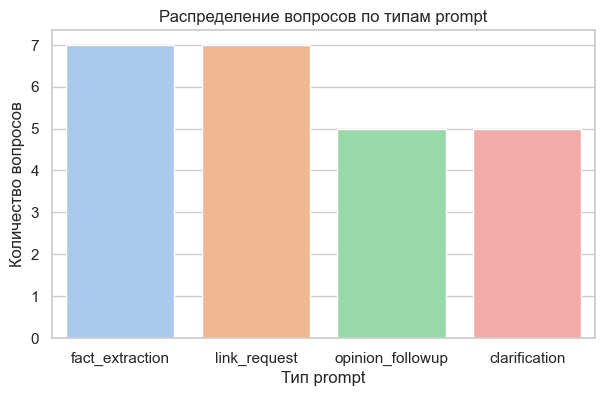

/var/folders/38/2h99w6rx1fz1qhgr17m1cbpm0000gn/T/ipykernel_33595/43788362.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='prompt_type', y='score_avg', data=gold_scored_df, palette='muted', order=["fact_extraction","link_request","opinion_followup","clarification"])


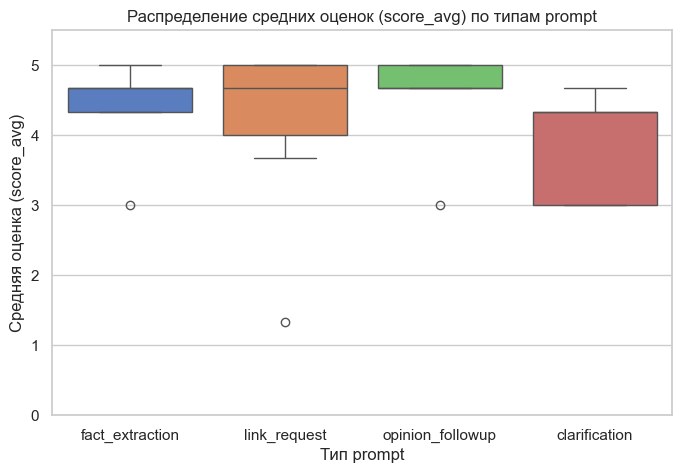

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки стиля
sns.set(style="whitegrid")

# 1️⃣ Распределение вопросов по типам prompt
plt.figure(figsize=(7,4))
sns.countplot(x='prompt_type', data=gold_scored_df, palette='pastel', order=["fact_extraction","link_request","opinion_followup","clarification"])
plt.title("Распределение вопросов по типам prompt")
plt.xlabel("Тип prompt")
plt.ylabel("Количество вопросов")
plt.show()

# 2️⃣ Средние оценки по типам prompt
plt.figure(figsize=(8,5))
sns.boxplot(x='prompt_type', y='score_avg', data=gold_scored_df, palette='muted', order=["fact_extraction","link_request","opinion_followup","clarification"])
plt.title("Распределение средних оценок (score_avg) по типам prompt")
plt.xlabel("Тип prompt")
plt.ylabel("Средняя оценка (score_avg)")
plt.ylim(0,5.5)
plt.show()


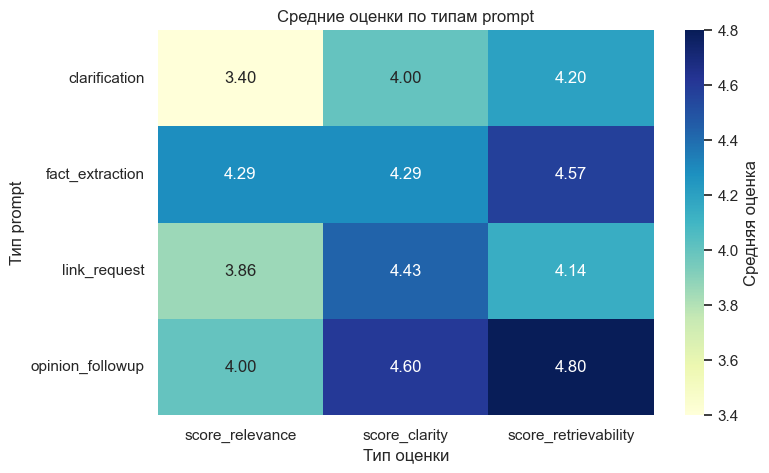

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Группируем по типу prompt и считаем средние значения по каждой оценке
heatmap_data = gold_scored_df.groupby('prompt_type')[['score_relevance','score_clarity','score_retrievability']].mean()

# Настройка размера графика
plt.figure(figsize=(8,5))

# Строим heatmap
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt=".2f", cbar_kws={'label': 'Средняя оценка'})
plt.title("Средние оценки по типам prompt")
plt.xlabel("Тип оценки")
plt.ylabel("Тип prompt")
plt.show()
